# Task 5: PCA Analysis

# Imports & Setup

In [15]:
import sys
from pathlib import Path
import os
import importlib
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))

import src.utils.config as config
importlib.reload(config)

# Loads paths from src.utils.config 

PLACENTA_DATA_T = config.PLACENTA_DATA_T
CORD_DATA_T = config.CORD_DATA_T
OUTPUTS_DIR = config.OUTPUTS_DIR
PCA_IMAGE_DIR = config.PCA_IMAGE_DIR
PCA_CSV_DIR = config.PCA_CSV_DIR

# Creates the new organized output folders for this notebook: a) 04_pca b)04_pca
PCA_IMAGE_04_DIR = os.path.join(PCA_IMAGE_DIR, "04_pca")
PCA_CSV_04_DIR = os.path.join(PCA_CSV_DIR, "04_pca")
os.makedirs(PCA_IMAGE_04_DIR, exist_ok=True)
os.makedirs(PCA_CSV_04_DIR, exist_ok=True)

print("PCA_IMAGE_04_DIR:", PCA_IMAGE_04_DIR)
print("PCA_CSV_04_DIR:", PCA_CSV_04_DIR)

PCA_IMAGE_04_DIR: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_images/04_pca
PCA_CSV_04_DIR: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/04_pca


# Load the Data

In [16]:
print("Loading transposed data (samples=rows, metabolites=cols)")
placenta_t = pd.read_csv(PLACENTA_DATA_T, index_col='Sample').astype(float)
cord_t     = pd.read_csv(CORD_DATA_T, index_col='Sample').astype(float)

print(f"Placenta: {placenta_t.shape} (samples × metabolites)")
print(f"Cord:     {cord_t.shape} (samples × metabolites)")
print("\nFirst 3 samples & metabolites:")
print(placenta_t.head(3).iloc[:, :3])


Loading transposed data (samples=rows, metabolites=cols)
Placenta: (40, 897) (samples × metabolites)
Cord:     (38, 981) (samples × metabolites)

First 3 samples & metabolites:
           1002002   1004006    107004
Sample                                
sample-1  1.067250  1.146871  1.005599
sample-2  0.846538  0.985189  1.003932
sample-3  0.928315  0.991967  0.970812


# PCA for Placenta ONLY

In [17]:
# PCA for Placenta and Cord separately
import re as _re
scaler_p = StandardScaler()
placenta_scaled = scaler_p.fit_transform(placenta_t)

scaler_c = StandardScaler()
cord_scaled = scaler_c.fit_transform(cord_t)

n_p = min(10, placenta_t.shape[1], placenta_t.shape[0])
n_c = min(10, cord_t.shape[1], cord_t.shape[0])

pca_p = PCA(n_components=n_p, random_state=42)
placenta_scores = pca_p.fit_transform(placenta_scaled)

pca_c = PCA(n_components=n_c, random_state=42)
cord_scores = pca_c.fit_transform(cord_scaled)

pcs = [f"PC{i+1}" for i in range(min(n_p, n_c))]
pc_cols_p = [f"PC{i+1}" for i in range(n_p)]
pc_cols_c = [f"PC{i+1}" for i in range(n_c)]

placenta_pca_df = pd.DataFrame(placenta_scores, index=placenta_t.index, columns=pc_cols_p)
cord_pca_df     = pd.DataFrame(cord_scores,     index=cord_t.index,     columns=pc_cols_c)

# --- Load Tube Labels from raw Sample Info sheets ---
p_si = pd.read_excel(config.PLACENTA_FILE, sheet_name="Sample Info", header=0)
p_label_map = dict(zip(p_si["SAMPLE ID"].astype(str), p_si["Tube Label"].astype(str)))
c_si = pd.read_excel(config.CORD_FILE, sheet_name="Sample Info", header=0)
c_label_map = dict(zip(c_si["SAMPLE ID"].astype(str), c_si["Tube Label"].astype(str)))

def _strip_placenta_label(x):
    return _re.sub(r'^[A-Za-z]+', '', str(x))

def _strip_cord_label(x):
    return _re.sub(r'[A-Za-z].*', '', str(x))

p_tube_labels = [_strip_placenta_label(p_label_map.get(s, "")) for s in placenta_pca_df.index]
c_tube_labels = [_strip_cord_label(c_label_map.get(s, "")) for s in cord_pca_df.index]

# Save-only copies with Tube_Label as second column; keep originals index-based for plots
placenta_save_df = placenta_pca_df.reset_index().rename(columns={"index": "Sample"})
placenta_save_df.insert(1, "Tube_Label", p_tube_labels)

cord_save_df = cord_pca_df.reset_index().rename(columns={"index": "Sample"})
cord_save_df.insert(1, "Tube_Label", c_tube_labels)

placenta_csv_path = os.path.join(PCA_CSV_04_DIR, "pca_placenta_only.csv")
cord_csv_path = os.path.join(PCA_CSV_04_DIR, "pca_cord_only.csv")
placenta_save_df.to_csv(placenta_csv_path, index=False)
cord_save_df.to_csv(cord_csv_path, index=False)

print(f"Placenta PCA scores shape: {placenta_pca_df.shape}")
print(f"Cord PCA scores shape:     {cord_pca_df.shape}")
print(placenta_pca_df.iloc[:3, :3].round(3))
print(f"Saved: {placenta_csv_path}")
print(f"Saved: {cord_csv_path}")

Placenta PCA scores shape: (40, 10)
Cord PCA scores shape:     (38, 10)
            PC1     PC2     PC3
Sample                         
sample-1 -1.837   9.675 -11.494
sample-2  5.119  -5.977  -4.488
sample-3  5.094  14.213  -3.279
Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/04_pca/pca_placenta_only.csv
Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/04_pca/pca_cord_only.csv


/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = no

In [18]:
placenta_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Sample,,,,,,,,,,
sample-1,-1.836882,9.674800,-11.493513,9.484060,0.099155,2.322369,-1.139683,-1.073316,-3.289946,-5.798883
sample-2,5.119141,-5.977017,-4.488253,-9.709202,5.965110,3.621359,1.531295,0.632809,-3.518376,2.380267
sample-3,5.093578,14.212926,-3.278799,-0.170095,-3.598092,21.238699,-2.550390,-0.526630,2.497083,-3.838249
sample-4,-8.885906,6.307899,-7.511825,-2.450200,1.929065,-3.779747,8.049089,2.565184,-5.789312,-3.894546
sample-5,5.511009,5.872692,-22.042687,5.401725,0.019815,-7.527623,-4.545568,-3.112662,2.277956,-1.828105


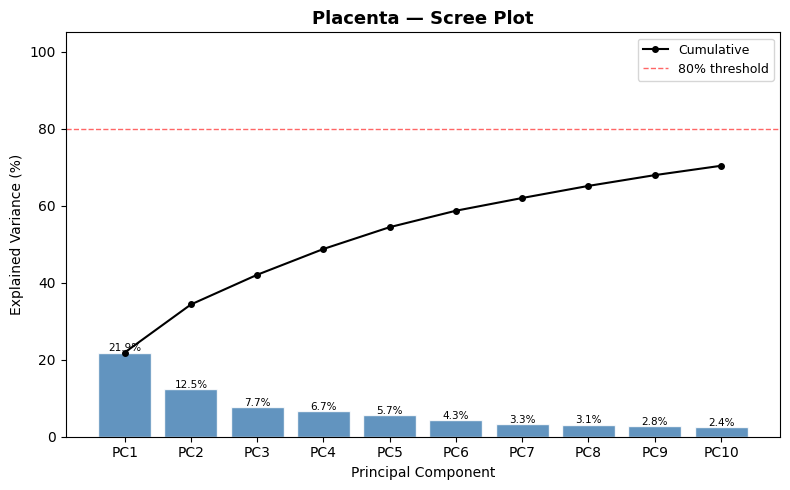

In [19]:
evr_p = pca_p.explained_variance_ratio_ * 100
cum_p = np.cumsum(evr_p)
pcs_p = [f"PC{i+1}" for i in range(len(evr_p))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pcs_p, evr_p, color='steelblue', edgecolor='white', alpha=0.85)
ax.plot(pcs_p, cum_p, color='black', marker='o', linewidth=1.5, markersize=4, label='Cumulative')
ax.axhline(80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='80% threshold')

for i, v in enumerate(evr_p):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=7.5)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Placenta — Scree Plot", fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PCA_IMAGE_04_DIR, "placenta_scree.png"), dpi=150, bbox_inches='tight')
plt.show()


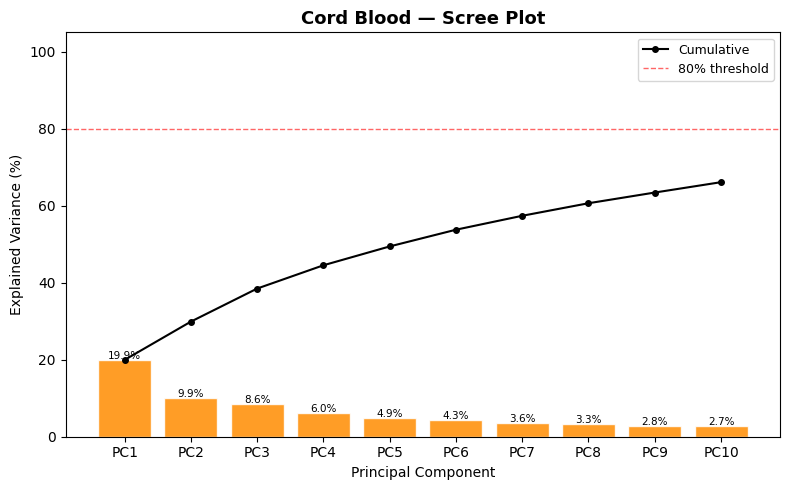

In [20]:
# ── Cord Blood Scree Plot ────────────────────────────────────────────────────
evr_c = pca_c.explained_variance_ratio_ * 100
cum_c = np.cumsum(evr_c)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pcs, evr_c, color='darkorange', edgecolor='white', alpha=0.85)
ax.plot(pcs, cum_c, color='black', marker='o', linewidth=1.5, markersize=4, label='Cumulative')
ax.axhline(80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='80% threshold')

for i, v in enumerate(evr_c):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=7.5)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Cord Blood — Scree Plot", fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PCA_IMAGE_04_DIR, "cord_scree.png"), dpi=150, bbox_inches='tight')
plt.show()

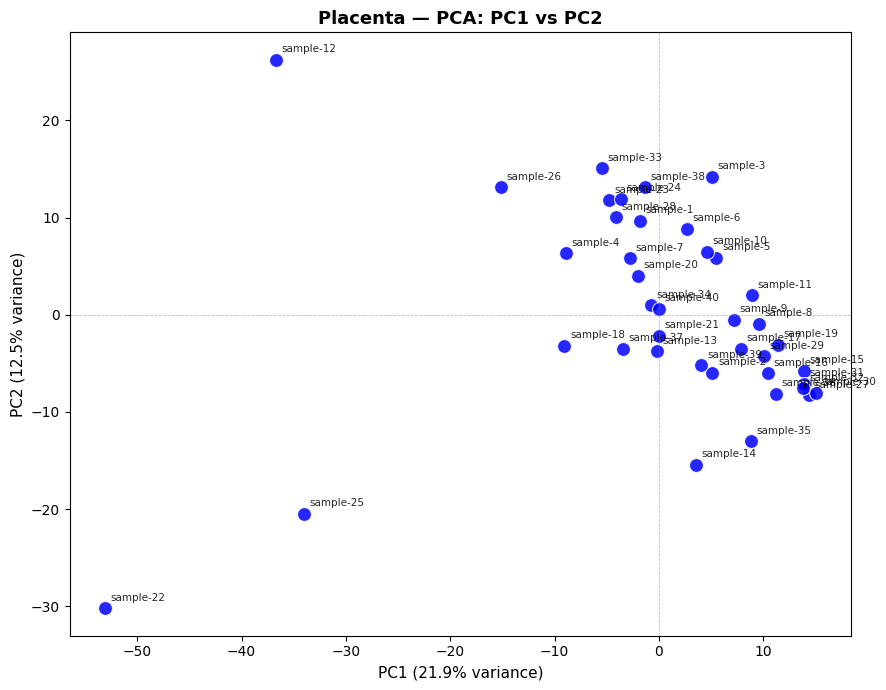

In [21]:
# ── Placenta: PC1 vs PC2 Scatter ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    placenta_pca_df['PC1'], placenta_pca_df['PC2'],
    color='blue', edgecolors='white', s=100, linewidths=0.8, alpha=0.85
)

# Annotate each sample
for sample, row in placenta_pca_df.iterrows():
    ax.annotate(
        sample, (row['PC1'], row['PC2']),
        fontsize=7.5, ha='left', va='bottom',
        xytext=(4, 4), textcoords='offset points', alpha=0.85
    )

ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel(f"PC1 ({evr_p[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({evr_p[1]:.1f}% variance)", fontsize=11)
ax.set_title("Placenta — PCA: PC1 vs PC2", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PCA_IMAGE_04_DIR, "placenta_pca_pc1_pc2.png"), dpi=150, bbox_inches='tight')
plt.show()

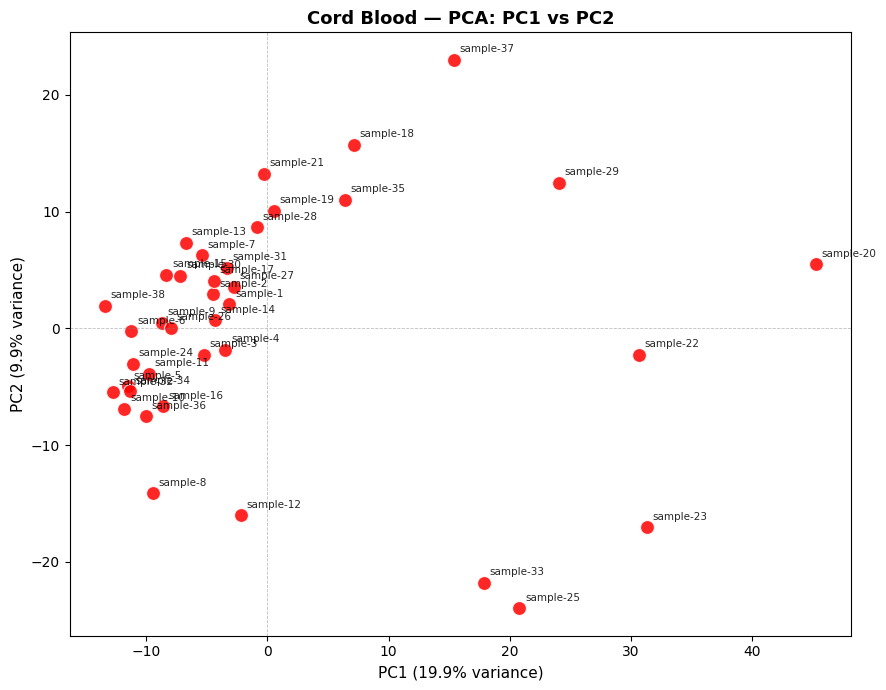

In [22]:
# ── Cord Blood: PC1 vs PC2 Scatter ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    cord_pca_df['PC1'], cord_pca_df['PC2'],
    color='red', edgecolors='white', s=100, linewidths=0.8, alpha=0.85
)

# Annotate each sample
for sample, row in cord_pca_df.iterrows():
    ax.annotate(
        sample, (row['PC1'], row['PC2']),
        fontsize=7.5, ha='left', va='bottom',
        xytext=(4, 4), textcoords='offset points', alpha=0.85
    )

ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel(f"PC1 ({evr_c[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({evr_c[1]:.1f}% variance)", fontsize=11)
ax.set_title("Cord Blood — PCA: PC1 vs PC2", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PCA_IMAGE_04_DIR, "cord_pca_pc1_pc2.png"), dpi=150, bbox_inches='tight')
plt.show()

# Combined PCA: Placenta + Cord (common metabolites from summary) 

In [23]:

print("Running combined PCA on Placenta + Cord (common metabolites from summary)")

summary_file = os.path.join(OUTPUTS_DIR, "summary_tables", "metabolites_common_cord_placenta.xlsx")
common_sheet = pd.read_excel(summary_file, sheet_name="Common")

# First column in summary sheet contains COMP IDs
common_from_summary = common_sheet.iloc[:, 0].astype(str).tolist()

# Keep only IDs that are present in both data matrices
common_metabolites = [
    comp_id for comp_id in common_from_summary
    if (comp_id in placenta_t.columns) and (comp_id in cord_t.columns)
]

placenta_common = placenta_t[common_metabolites].copy()
cord_common = cord_t[common_metabolites].copy()

combined_df = pd.concat([placenta_common, cord_common], axis=0)
combined_group = pd.Series(
    ["Placenta"] * len(placenta_common) + ["Cord"] * len(cord_common),
    index=combined_df.index,
    name="Group"
 )



Running combined PCA on Placenta + Cord (common metabolites from summary)


In [24]:
combined_df.head()

,107004,108005,109011,1101006,1102005,1102017,1102019,1102028,1102031,1102033,...,675023,675024,675025,675026,675027,675028,675029,676007,677004,677011
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,1.005599,1.028547,1.005848,1.017847,0.893673,0.873139,0.838858,0.922293,0.976964,0.953312,...,0.986747,0.994370,1.000380,0.992389,0.995633,1.003121,1.015811,1.008183,0.993579,0.991678
sample-2,1.003932,0.992848,0.999033,0.991056,0.893673,0.967531,1.015159,0.882013,1.068998,1.080846,...,0.989247,1.005602,1.006957,1.003757,1.023405,0.983785,1.008291,0.979877,0.970319,1.002502
sample-3,0.970812,1.028489,1.020683,0.999784,0.893673,1.176311,1.067498,1.244669,1.215472,1.152647,...,0.994467,0.993673,0.990103,0.999519,1.003467,0.991889,0.988243,1.016172,1.001665,1.003265
sample-4,0.997856,1.030684,0.983982,0.995086,0.893673,0.873139,0.916150,0.900731,0.982119,1.074760,...,0.998702,0.978831,0.972205,0.972489,0.975934,0.994323,0.986412,0.979119,0.977793,0.979333
sample-5,1.018498,1.043982,1.000493,0.980575,0.893673,0.873139,0.838858,0.869978,0.952819,0.844005,...,1.050947,1.017755,1.041919,1.013411,0.998258,0.999595,1.022783,1.006994,1.002254,1.004080


In [25]:
combined_group.value_counts()

Group
Placenta    40
Cord        38
Name: count, dtype: int64

In [26]:
scaler_combined = StandardScaler()
combined_scaled = scaler_combined.fit_transform(combined_df)

if not np.isfinite(combined_scaled).all():
    raise ValueError("Non-finite values in combined_scaled. Check input / imputation.")

pca_combined = PCA(n_components=10, random_state=42)
combined_scores = pca_combined.fit_transform(combined_scaled)

combined_cols = [f"PC{i+1}" for i in range(combined_scores.shape[1])]
combined_pca_df = pd.DataFrame(combined_scores, index=combined_df.index, columns=combined_cols)
combined_pca_df["Group"] = combined_group

combined_csv_path = os.path.join(PCA_CSV_04_DIR, "pca_combined_placenta_cord.csv")
combined_pca_df.to_csv(combined_csv_path)

evr_combined = pca_combined.explained_variance_ratio_ * 100
print(f"\nCommon IDs in summary file:      {len(common_from_summary)}")
print(f"Common metabolites used in PCA: {len(common_metabolites)}")
print(f"Combined input shape:           {combined_df.shape}")
print(f"Combined PCA scores shape:      {combined_pca_df.shape}")
print(f"First 5 explained variance (%): {np.round(evr_combined[:5], 2)}")
print(f"Saved: {combined_csv_path}")


Common IDs in summary file:      698
Common metabolites used in PCA: 698
Combined input shape:           (78, 698)
Combined PCA scores shape:      (78, 11)
First 5 explained variance (%): [16.98 10.25  6.23  5.67  4.45]
Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/04_pca/pca_combined_placenta_cord.csv


/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = no

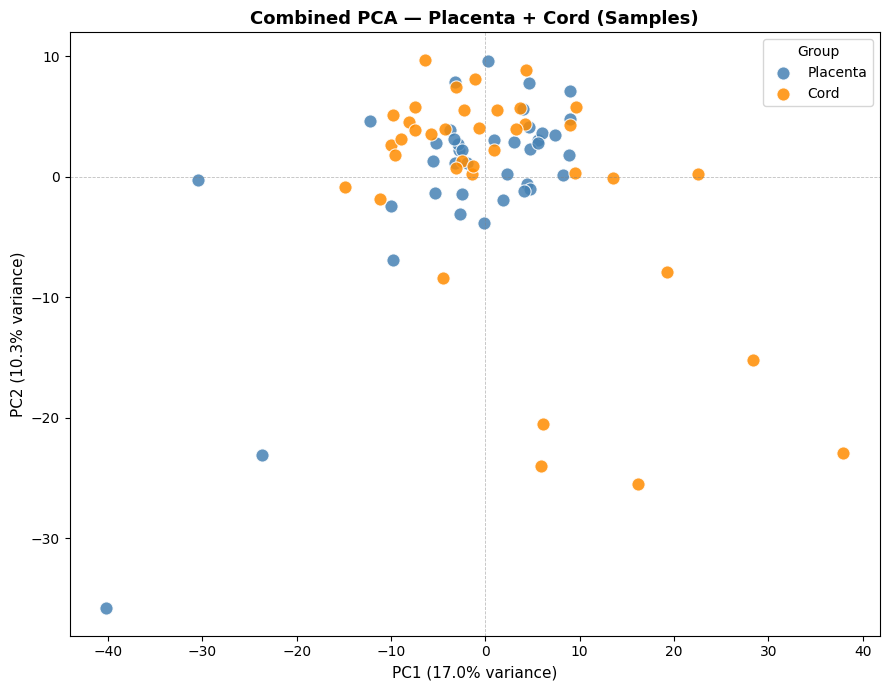

Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_images/04_pca/combined_placenta_cord_pc1_pc2.png


In [27]:
# ── Combined PCA Scatter: PC1 vs PC2 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for label, color in [("Placenta", "steelblue"), ("Cord", "darkorange")]:
    subset = combined_pca_df[combined_pca_df["Group"] == label]
    ax.scatter(
        subset["PC1"], subset["PC2"],
        label=label, color=color, edgecolors='white', s=90, linewidths=0.8, alpha=0.85
    )

ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel(f"PC1 ({evr_combined[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({evr_combined[1]:.1f}% variance)", fontsize=11)
ax.set_title("Combined PCA — Placenta + Cord (Samples)", fontsize=13, fontweight='bold')
ax.legend(title="Group")
plt.tight_layout()

plot_path = os.path.join(PCA_IMAGE_04_DIR, "combined_placenta_cord_pc1_pc2.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print("Saved:", plot_path)

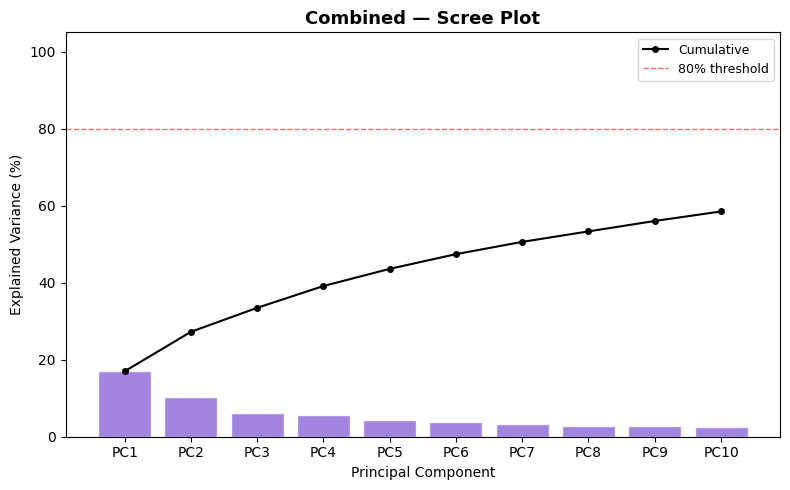

Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_images/04_pca/combined_scree.png


In [28]:
# ── Combined PCA Scree Plot ───────────────────────────────────────────────────
evr_combined_full = pca_combined.explained_variance_ratio_ * 100
cum_combined = np.cumsum(evr_combined_full)
pcs_combined = [f"PC{i+1}" for i in range(len(evr_combined_full))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pcs_combined, evr_combined_full, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.plot(pcs_combined, cum_combined, color='black', marker='o', linewidth=1.5, markersize=4, label='Cumulative')
ax.axhline(80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='80% threshold')

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Combined — Scree Plot", fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
plt.tight_layout()

scree_path = os.path.join(PCA_IMAGE_04_DIR, "combined_scree.png")
plt.savefig(scree_path, dpi=150, bbox_inches='tight')
plt.show()

print("Saved:", scree_path)